In [1]:
import numpy as np
import matplotlib.pyplot as plt

def D_avancada(u, bar_x, h):
    # Calcula D_{+}u(\bar{x})

    return (u(bar_x+h) - u(bar_x)) / h

def D_atrasada(u, bar_x, h):
    # Calcula D_{-}u(\bar{x})

    return (u(bar_x) - u(bar_x-h)) / h

def D_centrada(u, bar_x, h):
    # Calcula D_{0}u(\bar{x})

    return (u(bar_x+h) - u(bar_x-h)) / (2*h)

def D_3(u, bar_x, h):
    # Calcula D_{3}u(\bar{x})

    return (2*u(bar_x+h) + 3*u(bar_x) - 6*u(bar_x-h) + u(bar_x-2*h)) \
        / (6*h)

In [2]:
### Define a função u, o ponto \bar{x} e os valores de h para varrer
u = np.sin
bar_x = 1
steps = [1.0e-1, 5.0e-2, 1.0e-2, 5.0e-3, 1.0e-3]

### Listas para armazenar os erros
erros_D_avancada = []
erros_D_atrasada = []
erros_D_centrada = []
erros_D_3 = []

### Calcula os erros e armazena nas listas para cada valor de h
for h in steps:
    erros_D_avancada.append(D_avancada(u, bar_x, h) - np.cos(1))
    erros_D_atrasada.append(D_atrasada(u, bar_x, h) - np.cos(1))
    erros_D_centrada.append(D_centrada(u, bar_x, h) - np.cos(1))
    erros_D_3.append(D_3(u, bar_x, h) - np.cos(1))

In [3]:
### Monta a Tabela 1.1 do LeVeque com os erros calculados
print('-'*69)
print(f' {'h':^7} | {'Erro D_+':^12}   {'Erro D_-':^12}   {'Erro D_0':^12}   {'Erro D_3':^12} ')
print('-'*69)
for i in range(len(steps)):
    h = steps[i]
    erro_avancada = erros_D_avancada[i]
    erro_atrasada = erros_D_atrasada[i]
    erro_centrada = erros_D_centrada[i]
    erro_3 = erros_D_3[i]
    print(f' {h:<1.1e} | {erro_avancada: 12.5e}   {erro_atrasada: 12.5e}   {erro_centrada: 1.5e}   {erro_3: 12.5e} ')
print('-'*69)

---------------------------------------------------------------------
    h    |   Erro D_+       Erro D_-       Erro D_0       Erro D_3   
---------------------------------------------------------------------
 1.0e-01 | -4.29386e-02    4.11384e-02   -9.00054e-04    6.82069e-05 
 5.0e-02 | -2.12575e-02    2.08073e-02   -2.25098e-04    8.64914e-06 
 1.0e-02 | -4.21632e-03    4.19831e-03   -9.00499e-06    6.99413e-08 
 5.0e-03 | -2.10592e-03    2.10142e-03   -2.25126e-06    8.75400e-09 
 1.0e-03 | -4.20826e-04    4.20645e-04   -9.00505e-08    6.99795e-11 
---------------------------------------------------------------------


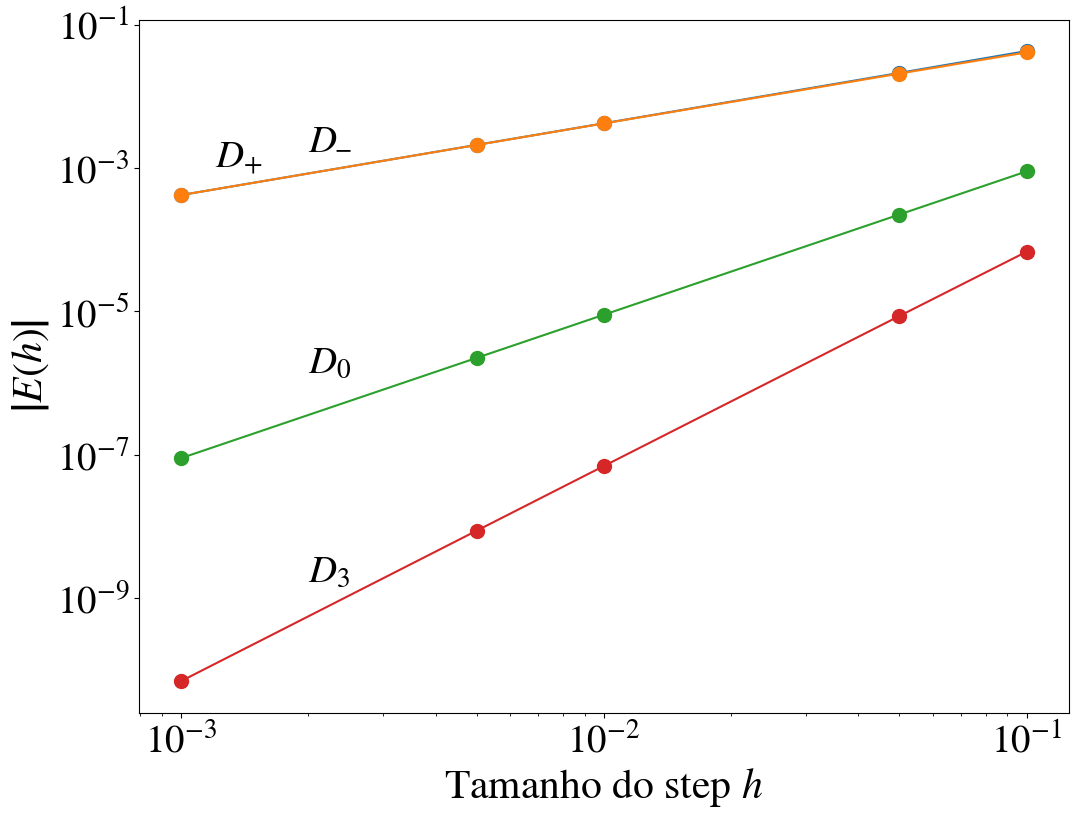

In [4]:
### Plota os erros em função de h em escala log log igual a Figura 1.2 do LeVeque
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

fig, ax = plt.subplots(figsize=(12,9))
ax.loglog(steps, np.abs(erros_D_avancada), 'o-', label=r'$D_{+}$', ms=10)
ax.loglog(steps, np.abs(erros_D_atrasada), 'o-', label=r'$D_{-}$', ms=10)
ax.loglog(steps, np.abs(erros_D_centrada), 'o-', label=r'$D_{0}$', ms=10)
ax.loglog(steps, np.abs(erros_D_3), 'o-', label='$D_3$', ms=10)

ax.text(1.2e-3, 1.0e-3, r'$D_{+}$', fontsize=28)
ax.text(2e-3, 1.7e-3, r'$D$', fontsize=28)
ax.text(2.3e-3, 1.54e-3, r'$-$', fontsize=18)
ax.text(2e-3, 1.4e-6, r'$D_{0}$', fontsize=28)
ax.text(2e-3, 1.7e-9, r'$D_{3}$', fontsize=28)

ax.tick_params(axis='both', which='major', labelsize=28)
ax.set_xlabel(r'Tamanho do step $h$', fontsize=30)
ax.set_ylabel(r'$\left|E(h)\right|$', fontsize=30)
plt.savefig('erros.svg')
plt.show()